In [2]:
!pip install transitleastsquares


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # so Python can find phast_bootstrap.py
import phast_bootstrap

[phast_bootstrap] ready. Colab paths now resolve under: C:\Users\Swara Deshpande\exoplanet-detection-isro


In [4]:
from google.colab import drive
drive.mount('/content/drive')

[pipeline] mock drive.mount — using local repo


In [5]:
import pickle
import numpy as np
from transitleastsquares import transitleastsquares
import matplotlib.pyplot as plt


In [6]:
load_path = "/content/drive/MyDrive/exoplanet_pipeline/data/stage1_output.pkl"

with open(load_path, "rb") as f:
    stage1_data = pickle.load(f)

print(stage1_data.keys())

dict_keys(['time', 'flux', 'flux_err', 'tic_id', 'crowdsap', 'ra', 'dec', 'sector'])


In [7]:
time = stage1_data["time"]
flux = stage1_data["flux"]
flux_err = stage1_data["flux_err"]

tic_id = stage1_data["tic_id"]
crowdsap = stage1_data["crowdsap"]

ra = stage1_data["ra"]
dec = stage1_data["dec"]

print("TIC:", tic_id)
print("Cadences:", len(time))
print("CROWDSAP:", crowdsap)

TIC: 261136679
Cadences: 18261
CROWDSAP: 0.99965841


In [8]:
print(type(flux))
print(flux.dtype)

<class 'astropy.utils.masked.core.MaskedNDArray'>
float64


In [9]:
time = np.asarray(time)
flux = np.asarray(flux)
flux_err = np.asarray(flux_err)

In [10]:
print(time.min())
print(time.max())
print(np.isnan(flux).sum())

-2455674.703039505
-2455646.8229341027
0


In [11]:
time_tls = time - np.min(time)

print("Min:", time_tls.min())
print("Max:", time_tls.max())

Min: 0.0
Max: 27.880105402320623


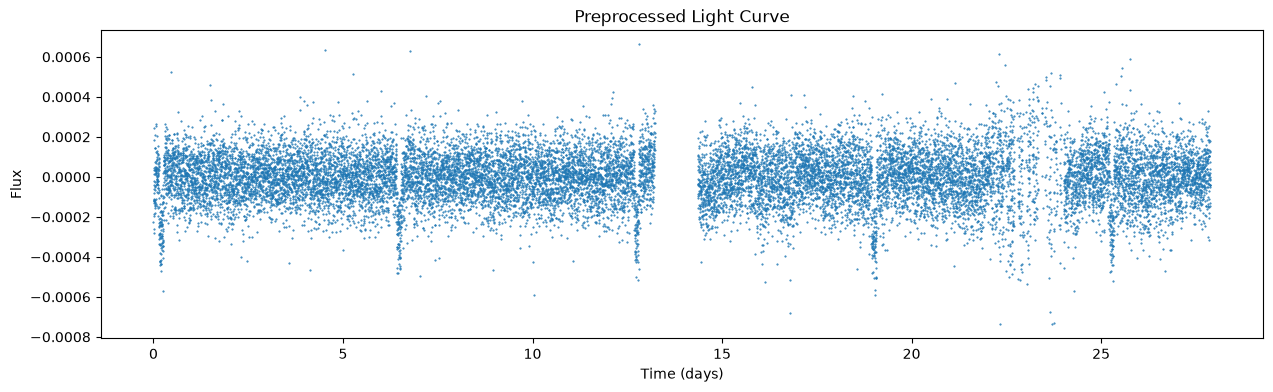

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(time_tls, flux, ".", markersize=1)

plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Preprocessed Light Curve")

plt.show()

In [13]:
results = transitleastsquares(time_tls, flux, flux_err).power()

print("Period   :", results.period)
print("SDE      :", results.SDE)
print("Depth    :", results.depth)
print("Duration :", results.duration)
print("T0       :", results.T0)

C:\Users\Swara Deshpande\exoplanet-detection-isro\.venv\Lib\site-packages\transitleastsquares\validate.py:31: UserWarning: Warning: The mean flux should be normalized to 1, but it was found to be 9.666567277014184e-05
  warnings.warn(text)


Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 9124 data points, 2552 periods from 0.601 to 13.933 days
Using all 12 CPU threads


  0%|          | 0/2552 periods | 00:00<?

  0%|          | 1/2552 periods | 00:15<10:43:10

  0%|          | 9/2552 periods | 00:15<52:07   

...

 98%|█████████▊| 2508/2552 periods | 00:25<00:00

 99%|█████████▉| 2534/2552 periods | 00:25<00:00

100%|██████████| 2552/2552 periods | 00:25<00:00

Searching for best T0 for period 11.71536 days


Period   : 11.715364039590032
SDE      : 6.667828322793564
Depth    : -0.17659054010233288
Duration : 0.7602410334069283
T0       : 5.3976468832813165


In [14]:
# TLS expects flux normalized around 1.0.
# Stage 1 detrending centers the light curve around 0,
# so we shift it back before transit search.

from transitleastsquares import transitleastsquares

flux_tls = flux + 1
model = transitleastsquares(
    time_tls,
    flux_tls
)

results = model.power()

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 18260 data points, 2553 periods from 0.602 to 13.939 days
Using all 12 CPU threads


  0%|          | 0/2553 periods | 00:00<?

  0%|          | 1/2553 periods | 00:12<9:02:09

  0%|          | 12/2553 periods | 00:12<32:41 

  1%|          | 26/2553 periods | 00:12<12:11

...

 97%|█████████▋| 2480/2553 periods | 00:22<00:00

 98%|█████████▊| 2508/2553 periods | 00:22<00:00

 99%|█████████▉| 2536/2553 periods | 00:23<00:00

100%|██████████| 2553/2553 periods | 00:23<00:00

Searching for best T0 for period 6.26709 days


In [15]:
print("Period:", results.period)

print("Duration:", results.duration)

print("Depth:", results.depth)

print("T0:", results.T0)

print("Transit Count:", results.distinct_transit_count)

print("SNR:", results.snr)

print("Odd Even Mismatch:", results.odd_even_mismatch)

Period: 6.267090136076321
Duration: 0.12476139841324797
Depth: 0.9997072757998143
T0: 0.20952101445453392
Transit Count: 5
SNR: 41.52733356602065
Odd Even Mismatch: 2.5324346844809584


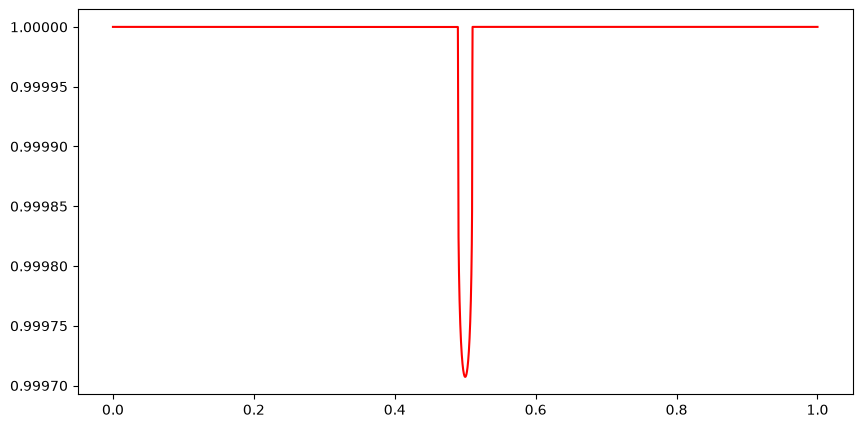

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(results.model_folded_phase,
         results.model_folded_model,
         color="red")

plt.show()

In [17]:
tls_features = {
    "period": float(results.period),
    "sde": float(results.SDE),
    "duration": float(results.duration),
    "t0": float(results.T0)
}

In [18]:
# ============================================================
# STAGE 2 OUTPUT EXPORT
# ============================================================

import os
import pickle

DATA_DIR = "/content/drive/MyDrive/exoplanet_pipeline/data"

os.makedirs(DATA_DIR, exist_ok=True)

stage2_data = {
    "period": float(results.period),
    "sde": float(results.SDE),
    "duration": float(results.duration),
    "t0": float(results.T0),

    "depth_tls": float(results.depth),
    "snr_tls": float(results.snr),

    "distinct_transit_count": int(
        results.distinct_transit_count
    ),

    "odd_even_mismatch_tls": float(
        results.odd_even_mismatch
    )
}

save_path = os.path.join(
    DATA_DIR,
    "stage2_output.pkl"
)

with open(save_path, "wb") as f:
    pickle.dump(stage2_data, f)

print("Stage 2 data saved successfully!")
print(save_path)
print(stage2_data)

Stage 2 data saved successfully!
/content/drive/MyDrive/exoplanet_pipeline/data\stage2_output.pkl
{'period': 6.267090136076321, 'sde': 17.69836307589993, 'duration': 0.12476139841324797, 't0': 0.20952101445453392, 'depth_tls': 0.9997072757998143, 'snr_tls': 41.52733356602065, 'distinct_transit_count': 5, 'odd_even_mismatch_tls': 2.5324346844809584}
